In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tensorflow.keras.datasets import mnist

In [2]:
from tensorflow.keras.datasets import fashion_mnist
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
print('Training Images:',x_train.shape[0])
print('Testing Images:',x_test.shape[0])
print('Image Dimensions:',x_train.shape[1:])

Training Images: 60000
Testing Images: 10000
Image Dimensions: (28, 28)


In [3]:
class_names=['T-shirt/Top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle Boot']

x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0

x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

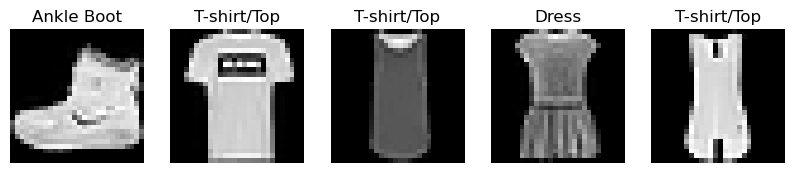

In [4]:
plt.figure(figsize=(10,5))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_train[i].reshape(28,28),cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [5]:
model=models.Sequential([
 layers.Input(shape=(28,28,1)),
 layers.Conv2D(32,(3,3),activation='relu'),
 layers.MaxPooling2D((2,2)),
 layers.Conv2D(64,(3,3),activation='relu'),
 layers.MaxPooling2D((2,2)),
 layers.Flatten(),
 layers.Dense(128,activation='relu'),
 layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS=20
BATCH_SIZE=32

history=model.fit(x_train,y_train,epochs=EPOCHS,batch_size=BATCH_SIZE,validation_split=0.1)

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8343 - loss: 0.4557 - val_accuracy: 0.8793 - val_loss: 0.3351
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8867 - loss: 0.3075 - val_accuracy: 0.8868 - val_loss: 0.3052
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9035 - loss: 0.2631 - val_accuracy: 0.8953 - val_loss: 0.2827
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9141 - loss: 0.2313 - val_accuracy: 0.9060 - val_loss: 0.2527
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.9238 - loss: 0.2043 - val_accuracy: 0.9108 - val_loss: 0.2449
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9316 - loss: 0.1807 - val_accuracy: 0.9168 - val_loss: 0.2336
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9399 - loss: 0.1588 - val_accuracy: 0.9157 - val_loss: 0.2462
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9472 - lo

In [7]:
print('Final Training Accuracy:',round(history.history['accuracy'][-1]*100,2),'%')
test_loss,test_acc=model.evaluate(x_test,y_test)
print('Test Accuracy:',round(test_acc*100,2),'%')

Final Training Accuracy: 98.61 %
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9073 - loss: 0.4830
Test Accuracy: 90.73 %


In [8]:
predictions=model.predict(x_test)
predicted_labels=np.argmax(predictions,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


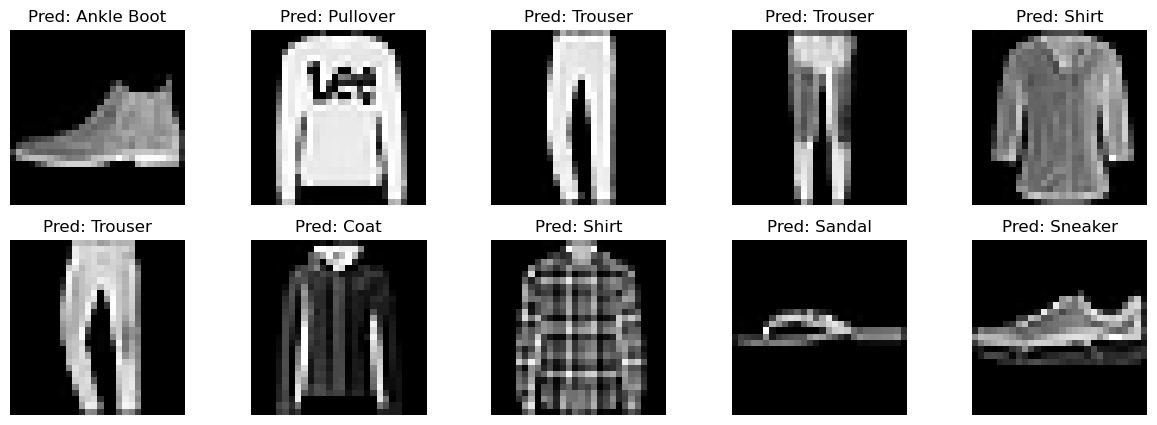

In [9]:
plt.figure(figsize=(15,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28),cmap='gray')
    plt.title(f'Pred: {class_names[predicted_labels[i]]}')
    plt.axis('off')
plt.show()

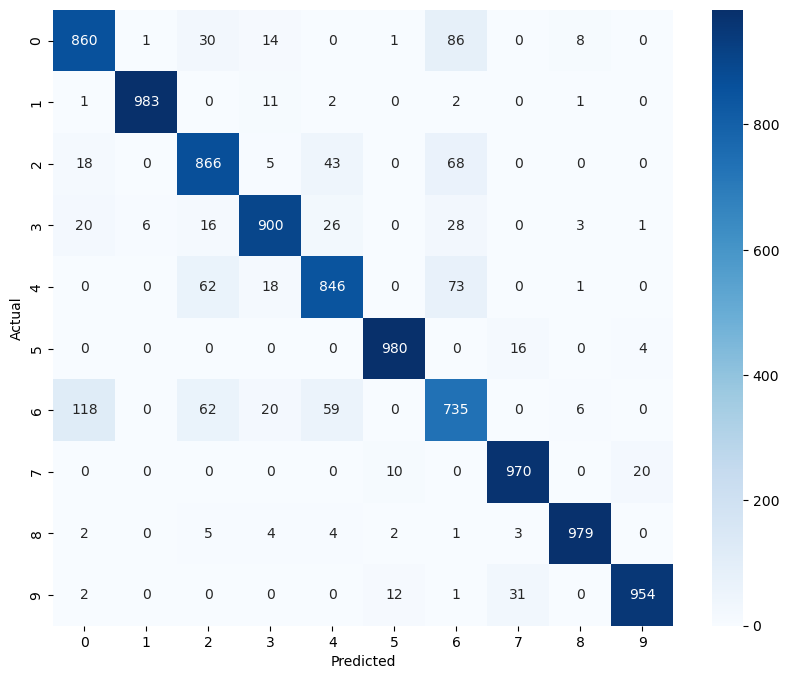

In [10]:
cm=confusion_matrix(y_test,predicted_labels)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [11]:
print(classification_report(y_test,predicted_labels,target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/Top       0.84      0.86      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.83      0.87      0.85      1000
       Dress       0.93      0.90      0.91      1000
        Coat       0.86      0.85      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.74      0.73      0.74      1000
     Sneaker       0.95      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle Boot       0.97      0.95      0.96      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

